<a href="https://colab.research.google.com/github/luqmarqs/especializacao-data-science/blob/main/Atividade_Pr%C3%A1tica_1_Python_para_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade Prática:** Pré-processamento e Análise de Dados de Marketing


**Objetivo:** Realizar a limpeza, análise exploratória gráfica e preparação dos dados para modelos de Machine Learning, baseando-se no framework de [Data Preprocessing in Machine Learning](https://www.kaggle.com/code/alirezahasannejad/data-preprocessing-in-machine-learning).

## **Passo 1 & 2: Importação de Bibliotecas e Preparação**

Nesta etapa, preparamos o ambiente com as ferramentas essenciais para manipulação de dados, visualização e modelagem.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Passo 3: Importação do Dataset**
O arquivo Customer marketing.csv utiliza tabulação (\t) como separador. Vamos carregá-lo e realizar uma inspeção inicial.

In [15]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Pergunta 1:** Quantos registros (linhas) e variáveis (colunas) o dataset possui? Quais variáveis são numéricas e quais são categóricas?

In [16]:
df = pd.read_csv('/content/drive/MyDrive/dados/Customer marketing.csv', sep =None, engine = 'python')

#forcei a leitura automática do separador


In [17]:
df.head()

,ID_,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [18]:
df.shape

(2240, 29)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_                  2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

O dataset possui 2240 registros e 29 colunas. Apenas 3 variáveis são categóricas: Education, Marital_Status e Dt_Customer, as demais são numéricas.

**ATENÇÃO** Aqui você precisará mudar o link "'/content/drive/...'" para o caminho que o arquivo estará no seu drive ou máquina.

### Análise Gráfica Inicial (Exploratória)

Antes de processar, precisamos "conhecer" os dados. Siga as instruções abaixo para gerar visualizações.

- **Pergunta 2:** Analisando o histograma de Income, você nota a presença de valores extremos (outliers)? Como esses valores podem impactar o cálculo da média?

<Axes: xlabel='Income', ylabel='Count'>

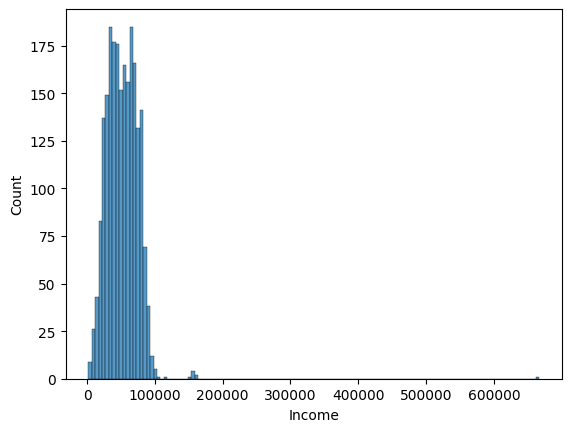

In [20]:
sns.histplot(df['Income'])

Ao analisar o histograma da variável Income, é possível observar a presença de valores extremos (outliers). A maior parte dos dados está concentrada em rendas mais baixas (até cerca de 100.000), enquanto poucos registros possuem valores muito altos, acima de 600.000.

Esses valores extremos deixam a distribuição assimétrica, com uma cauda à direita.

Eles também afetam o cálculo da média, pois valores muito altos puxam a média para cima, fazendo com que ela não represente bem a maioria dos dados.

- **Pergunta 3:** Qual nível de escolaridade parece apresentar a maior mediana de renda?

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Basic'),
  Text(1, 0, '2n Cycle'),
  Text(2, 0, 'Master'),
  Text(3, 0, 'Graduation'),
  Text(4, 0, 'PhD')])

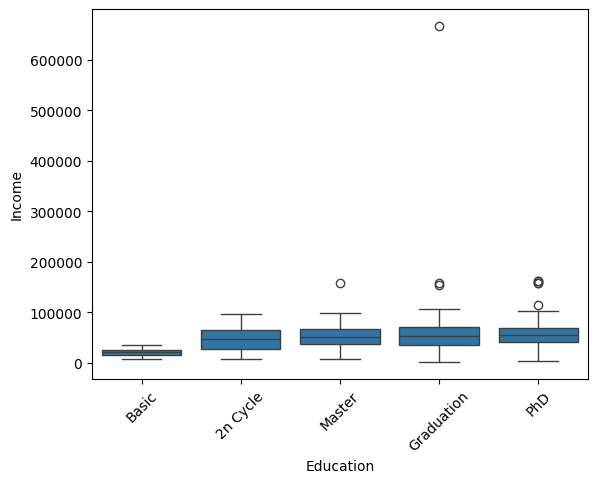

In [21]:
order = df.groupby('Education')['Income'].median().sort_values().index

sns.boxplot(x='Education', y='Income', data=df, order=order)
plt.xticks(rotation=45)

Ao analisar o boxplot ordenado pela mediana da renda, observa-se que o nível de escolaridade PhD apresenta a maior mediana de Income, pois aparece na posição mais alta entre as categorias.

A ordenação facilita a visualização e confirma que níveis mais altos de escolaridade estão associados a maiores rendas no dataset.

## **Passo 4: Identificando e Tratando Valores Ausentes**

Dados do mundo real costumam ser incompletos. Vamos verificar a integridade da nossa base.

- **Pergunta 4:** A coluna Income possui valores nulos. Sabendo que existem outliers (vistos no Passo Anterior), qual estratégia de preenchimento é mais segura: Média ou Mediana? Por quê?

**Tarefa Prática:** Implemente o preenchimento dos valores nulos na coluna Income utilizando a estratégia escolhida (na pergunta 4).

A mediana é mais adequada, pois não é afetada por outliers, ao contrário da média, que pode ser distorcida por valores extremos.

In [22]:
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Income'].isnull().sum()

np.int64(0)

## **Passo 5:** Codificação de Dados Categóricos
Modelos matemáticos exigem números. Variáveis como Education e Marital_Status precisam ser transformadas.

- **Pergunta 5:** Explique a diferença entre OneHotEncoding e OrdinalEncoding. Em que situação o OrdinalEncoding seria preferível para a coluna Education?

O One-Hot Encoding cria colunas separadas para cada categoria, sem considerar ordem. Já o Ordinal Encoding transforma as categorias em números, mantendo uma relação de ordem.

O Ordinal Encoding é preferível para a coluna Education quando consideramos que existe uma hierarquia entre os níveis de escolaridade, como do básico até o doutorado.
O uso de Ordinal Encoding pode ajudar o modelo a capturar melhor a relação entre nível educacional e renda.

In [23]:
#INCOME
mapping = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}

df['Education'] = df['Education'].map(mapping)
#Foi utilizado Ordinal Encoding manual na variável Education para preservar a hierarquia entre os níveis de escolaridade.

############

#MARITAL_STATUS
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)
#A variável Marital_Status foi codificada utilizando One-Hot Encoding, pois não possui uma ordem natural entre suas categorias. Esse método evita que o modelo interprete relações inexistentes entre os valores categóricos.

############

#DT_CUSTOMER
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df['Days_Customer'] = (pd.Timestamp.today() - df['Dt_Customer']).dt.days
df.drop('Dt_Customer', axis=1, inplace=True)

#A variável Dt_Customer foi convertida para o tipo datetime e transformada em uma nova variável (Days_Customer), que representa o tempo de relacionamento do cliente com a empresa.
#Essa transformação é importante porque modelos de machine learning não interpretam datas diretamente, sendo necessário convertê-las em valores numéricos mais informativos.



In [24]:
df.head()

,ID_,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,Z_Revenue,Response,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Days_Customer
0,5524,1957,2,58138.0,0,0,58,635,88,546,...,11,1,False,False,False,True,False,False,False,4947
1,2174,1954,2,46344.0,1,1,38,11,1,6,...,11,0,False,False,False,True,False,False,False,4397
2,4141,1965,2,71613.0,0,0,26,426,49,127,...,11,0,False,False,False,False,True,False,False,4596
3,6182,1984,2,26646.0,1,0,26,11,4,20,...,11,0,False,False,False,False,True,False,False,4423
4,5324,1981,4,58293.0,1,0,94,173,43,118,...,11,0,False,False,True,False,False,False,False,4445
